In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

## mean variance estimators from past returns

### note on diagonal shrinkage: why? choose other? keep?

In [2]:
def shrink_cov(S, alpha=0.1):
    """Simple diagonal shrinkage."""
    D = np.diag(np.diag(S))
    return (1 - alpha) * S + alpha * D

def estimate_mu_sigma(window_rets, cov_shrink_alpha=0.0, mean_shrink_beta=0.0):
    X = window_rets.to_numpy()
    mu = X.mean(axis=0)
    if mean_shrink_beta > 0:
        mu = (1 - mean_shrink_beta) * mu  # shrink toward 0

    S = np.cov(X, rowvar=False, ddof=1)
    if cov_shrink_alpha > 0:
        S = shrink_cov(S, alpha=cov_shrink_alpha)

    # small ridge for numerical stability
    S = S + 1e-8 * np.eye(S.shape[0])
    return mu, S


## numeric portfolio optimizer

In [ ]:
def solve_markowitz_cvxpy(mu, Sigma, w_prev=None, lam=10.0,
                          long_only=True, w_max=None,
                          turnover_penalty=0.0, turnover_limit=None):
    """
    Maximize mu'w - lam * w'Sigma w - turnover_penalty * ||w-w_prev||_1
    with constraints.
    """
    n = len(mu)

    #weights to optimize
    w = cp.Variable(n)

    #variance term
    risk = cp.quad_form(w, Sigma)  
    #return term
    ret = mu @ w

    obj = ret - lam * risk

    #optional turnover penalty
    if (w_prev is not None) and (turnover_penalty > 0):
        obj = obj - turnover_penalty * cp.norm1(w - w_prev)

    constraints = [cp.sum(w) == 1]

    #optional long only constraint
    if long_only:
        constraints += [w >= 0]


    #optional simultaneous max weight constraint 
    if w_max is not None:
        constraints += [w <= w_max]

    #optional turnover limit constraint
    if (w_prev is not None) and (turnover_limit is not None):
        constraints += [cp.norm1(w - w_prev) <= turnover_limit]

    prob = cp.Problem(cp.Maximize(obj), constraints)


    prob.solve(solver=cp.OSQP, verbose=False)

    if w.value is None:
        raise RuntimeError(f"Optimization failed. Status: {prob.status}")

    return np.asarray(w.value).ravel()

## Rolling Markowitzs strategy backtest

In [19]:
def backtest_markowitz(rets, L=15, lam=10.0,
                       rolling=True,
                       long_only=False, w_max=None,
                       cov_shrink_alpha=0.0, mean_shrink_beta=0.0,
                       turnover_penalty=0.0, turnover_limit=None):
    """
    Monthly rebalance (Option A: decision-time indexing):
    - at time t, estimate from window ending at t (inclusive),
      choose weights w_t (ACTION at t),
      realize next month return using r_{t+1} (REWARD for transition t -> t+1).
    Returns:
      port_rets[t] = w_t' r_{t+1}   (reward aligned to decision time t)
      weights[t]   = w_t
    """
    rets = rets.dropna(axis=0, how="any")
    T, n = rets.shape

    weights = []
    dates = []
    port_rets = []

    w_prev = None

    for t in range(L-1, T-1):
        if rolling:
            window = rets.iloc[t-(L-1):t+1]
        else:
            window = rets.iloc[:t+1]

        mu, Sigma = estimate_mu_sigma(window,
                                      cov_shrink_alpha=cov_shrink_alpha,
                                      mean_shrink_beta=mean_shrink_beta)

        w_t = solve_markowitz_cvxpy(mu, Sigma, w_prev=w_prev, lam=lam,
                                    long_only=long_only, w_max=w_max,
                                    turnover_penalty=turnover_penalty,
                                    turnover_limit=turnover_limit)

        # reward realized over next month
        r_next = float(w_t @ rets.iloc[t+1].to_numpy())

        # ---- key change: index by decision time t, not realization time t+1 ----
        dates.append(rets.index[t])
        weights.append(w_t)
        port_rets.append(r_next)

        w_prev = w_t

    weights = pd.DataFrame(weights, index=dates, columns=rets.columns)
    port_rets = pd.Series(port_rets, index=dates, name="portfolio_return_next")

    return port_rets, weights

### How to interpret the outputs (Option A: decision-time indexing)

- **`weights.loc[t]`**: the portfolio weights \(w_t\) chosen at month-end **\(t\)** (the **action** taken at time \(t\)).

- **`port_rets.loc[t]`**: the **next month’s** realized portfolio return
  \[
  r_{p,t+1} \;=\; w_t^\top r_{t+1},
  \]
  i.e., the **reward** produced by taking action \(w_t\) at time \(t\) and then observing returns over \((t, t+1]\).


In [ ]:
port_rets, port_ws = backtest_markowitz(rets)

In [18]:
port_ws.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
2017-05-31,0.130877,-0.390703,-0.211280,1.009704,0.461402
2017-06-30,-0.006122,-0.262695,-0.485687,0.896564,0.857940
2017-07-31,0.471365,-0.679319,-0.425136,0.924475,0.708615
2017-08-31,0.442411,-0.652382,-0.430448,0.933713,0.706707
2017-09-30,0.626328,-0.608199,-0.080275,0.798518,0.263628


### make clear this date convention

In [17]:
port_rets.head()

2017-05-31    0.048837
2017-06-30   -0.063108
2017-07-31    0.073065
2017-08-31   -0.043264
2017-09-30   -0.020150
Name: portfolio_return, dtype: float64

In [20]:
port_rets_realized = port_rets.copy()
port_rets_realized.index = rets.index[port_rets.index.get_indexer(port_rets.index) + 1]
# easier if you build it in-loop too; but this keeps the benchmark “Option A” canonical.


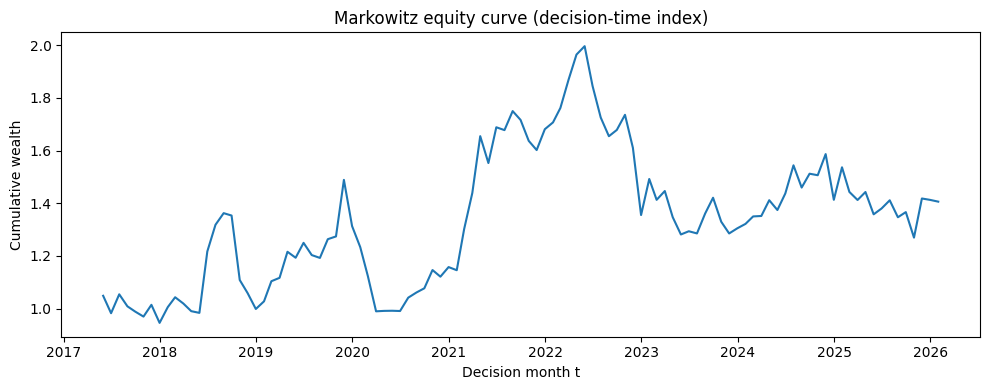

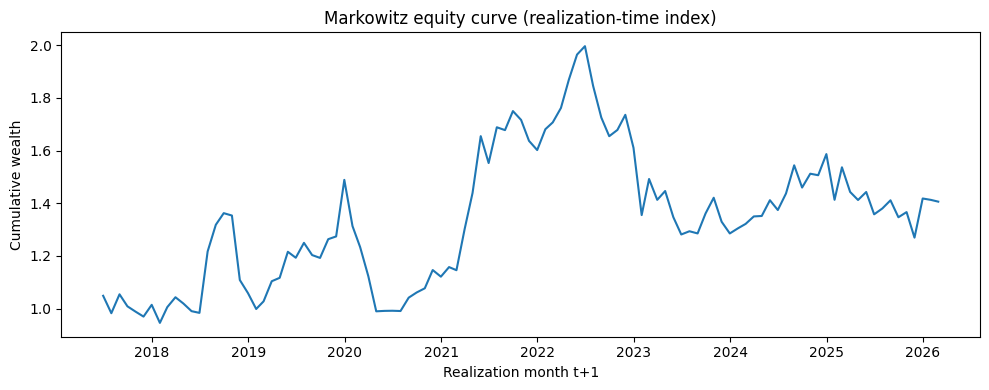

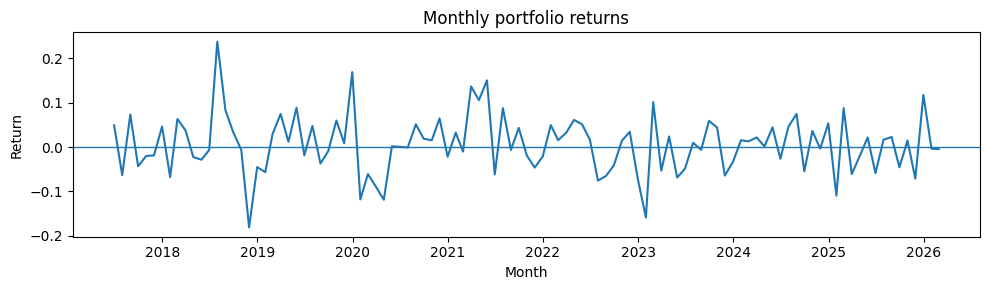

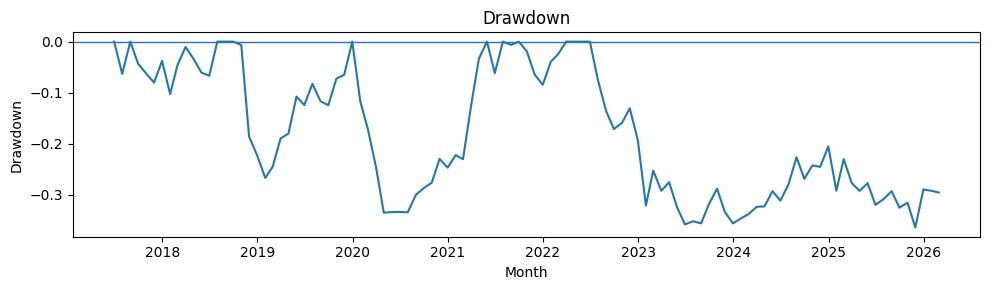

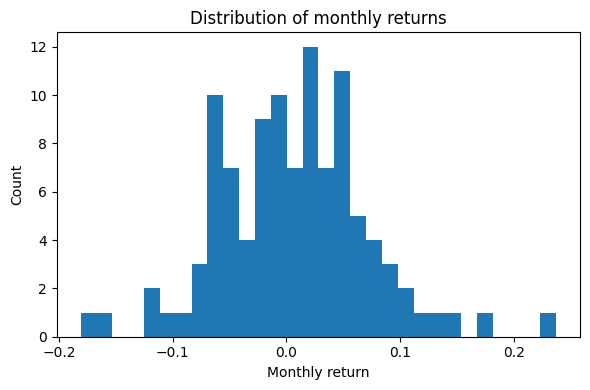

In [ ]:
# port_rets: pd.Series of monthly returns (decision-time indexed)

# --- 1) Equity curve (as-is: indexed by decision time t, returns are r_{t+1}) ---
equity = (1.0 + port_rets).cumprod()

plt.figure(figsize=(10,4))
plt.plot(equity)
plt.title("Markowitz equity curve (decision-time index)")
plt.xlabel("Decision month t")
plt.ylabel("Cumulative wealth")
plt.tight_layout()
plt.show()

# --- 2) Optional: re-index to realization time (label returns by t+1) ---
# If your index is month-end timestamps, this gives the reporting convention.
port_rets_realized = port_rets.copy()
port_rets_realized.index = port_rets_realized.index + pd.offsets.MonthEnd(1)

equity_realized = (1.0 + port_rets_realized).cumprod()

plt.figure(figsize=(10,4))
plt.plot(equity_realized)
plt.title("Markowitz equity curve (realization-time index)")
plt.xlabel("Realization month t+1")
plt.ylabel("Cumulative wealth")
plt.tight_layout()
plt.show()

# --- 3) Returns time series (monthly) ---
plt.figure(figsize=(10,3))
plt.plot(port_rets_realized)  # or port_rets
plt.axhline(0.0, linewidth=1)
plt.title("Monthly portfolio returns")
plt.xlabel("Month")
plt.ylabel("Return")
plt.tight_layout()
plt.show()

# --- 4) Drawdown plot ---
roll_max = equity_realized.cummax()
drawdown = equity_realized / roll_max - 1.0

plt.figure(figsize=(10,3))
plt.plot(drawdown)
plt.axhline(0.0, linewidth=1)
plt.title("Drawdown")
plt.xlabel("Month")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

# --- 5) Histogram of monthly returns ---
plt.figure(figsize=(6,4))
plt.hist(port_rets_realized.values, bins=30)
plt.title("Distribution of monthly returns")
plt.xlabel("Monthly return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


###for cumulative returns PLOTS, leave the relization date

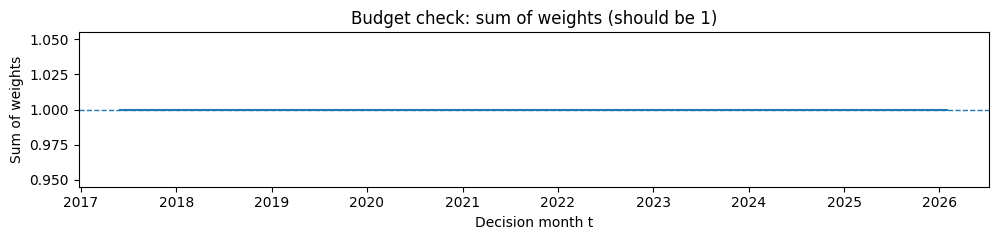

Weights include negatives (shorts). Use the long/short split plots below.


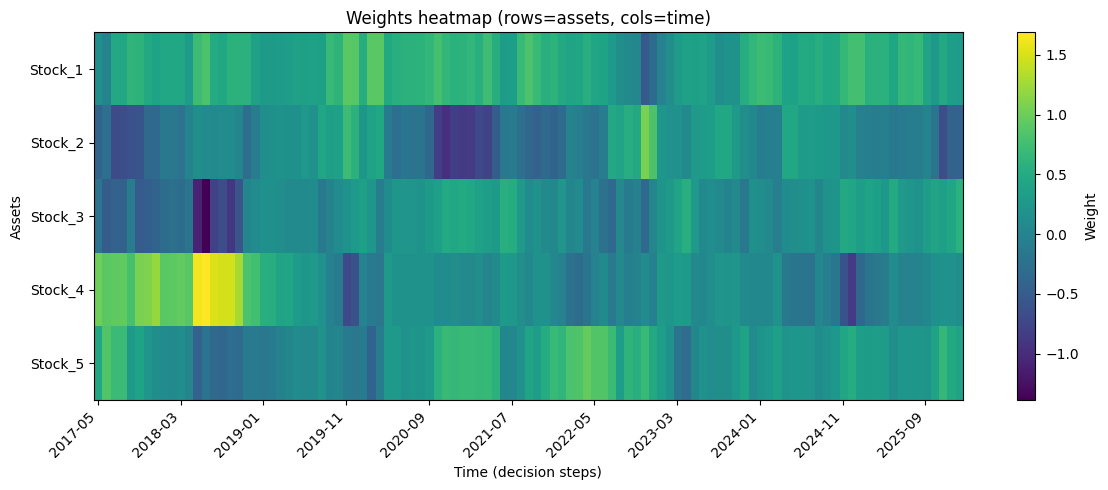

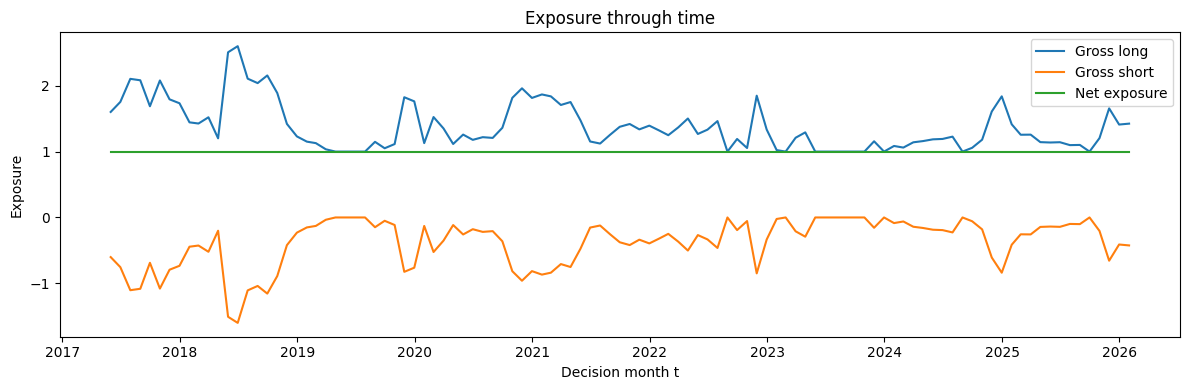

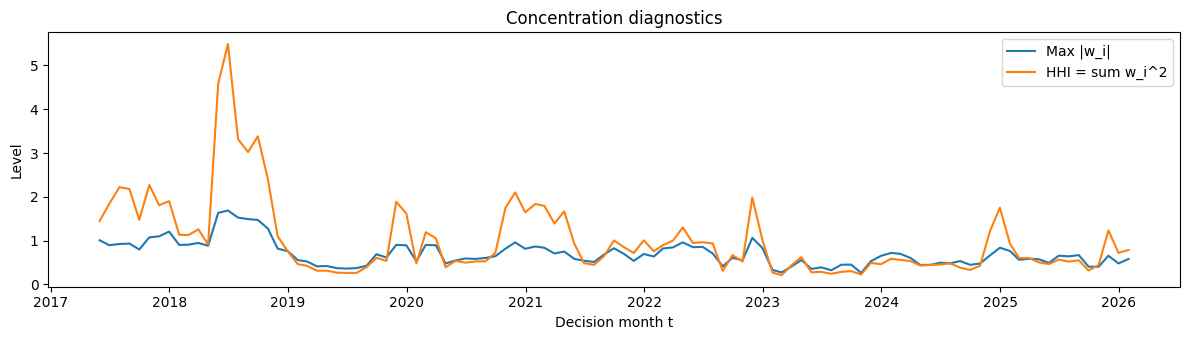

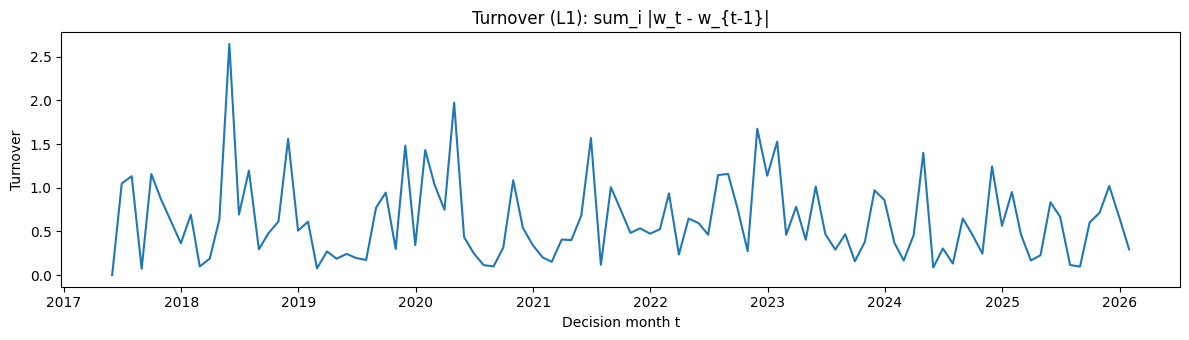

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# weights: pd.DataFrame (T_bt x n), index = decision dates, columns = asset names

# --- 0) Quick sanity checks ---
plt.figure(figsize=(10,2.5))
plt.plot(port_ws.sum(axis=1))
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Budget check: sum of weights (should be 1)")
plt.xlabel("Decision month t")
plt.ylabel("Sum of weights")
plt.tight_layout()
plt.show()

# --- 1) Stacked area chart of weights over time (best when long-only) ---
W = port_ws.copy()

# If you allow shorts, a stacked area can be misleading; see the long/short split below.
if (W.values >= -1e-12).all():
    plt.figure(figsize=(12,5))
    plt.stackplot(W.index, W.T.values, labels=W.columns)
    plt.title("Portfolio weights over time (stacked area)")
    plt.xlabel("Decision month t")
    plt.ylabel("Weight")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
    plt.tight_layout()
    plt.show()
else:
    print("Weights include negatives (shorts). Use the long/short split plots below.")

# --- 2) Heatmap of weights (works for long/short too) ---
plt.figure(figsize=(12,5))
plt.imshow(W.T.values, aspect="auto", interpolation="nearest")
plt.title("Weights heatmap (rows=assets, cols=time)")
plt.xlabel("Time (decision steps)")
plt.ylabel("Assets")
plt.yticks(np.arange(W.shape[1]), W.columns)

# optional x tick labels (sparse so it doesn't clutter)
step = max(1, W.shape[0] // 10)
xticks = np.arange(0, W.shape[0], step)
plt.xticks(xticks, [W.index[i].strftime("%Y-%m") for i in xticks], rotation=45, ha="right")

plt.colorbar(label="Weight")
plt.tight_layout()
plt.show()

# --- 3) If you have shorts: visualize long vs short exposure separately ---
if (W.values < -1e-12).any():
    W_long = W.clip(lower=0.0)
    W_short = (W.clip(upper=0.0))  # positive magnitudes of shorts

    plt.figure(figsize=(12,4))
    plt.plot(W_long.sum(axis=1), label="Gross long")
    plt.plot(W_short.sum(axis=1), label="Gross short")
    plt.plot((W_long.sum(axis=1) + W_short.sum(axis=1)), label="Net exposure")
    plt.title("Exposure through time")
    plt.xlabel("Decision month t")
    plt.ylabel("Exposure")
    plt.legend()
    plt.tight_layout()
    plt.show()



# --- 4) Concentration: top weight / Herfindahl (HHI) ---
absW = port_ws.abs()
top1 = absW.max(axis=1)
hhi = (port_ws**2).sum(axis=1)  # for long-only, HHI in [1/n, 1]

plt.figure(figsize=(12,3.5))
plt.plot(top1, label="Max |w_i|")
plt.plot(hhi, label="HHI = sum w_i^2")
plt.title("Concentration diagnostics")
plt.xlabel("Decision month t")
plt.ylabel("Level")
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) Turnover: ||w_t - w_{t-1}||_1 ---
turnover = port_ws.diff().abs().sum(axis=1)

plt.figure(figsize=(12,3.5))
plt.plot(turnover)
plt.title("Turnover (L1): sum_i |w_t - w_{t-1}|")
plt.xlabel("Decision month t")
plt.ylabel("Turnover")
plt.tight_layout()
plt.show()


### Sample stock data

In [5]:
def simulate_gbm_prices(
    n_months: int,
    S0,
    mu_annual,
    sigma_annual,
    corr_mat,
    start: str = "2016-01-31",
    seed: int = 42,
):
    """
    Simulate monthly GBM prices with *asset-specific* drift/vol and a full correlation matrix.

    Model (per asset i):
      d log S_i = (mu_i - 0.5 sigma_i^2) dt + sigma_i dW_i
    with corr(dW) = corr_mat and dt = 1/12 (monthly).

    Parameters
    ----------
    n_months : int
        Number of monthly steps (returns). Prices will have n_months+1 rows.
    S0 : float or array-like (n,)
        Initial prices.
    mu_annual : array-like (n,)
        Annualized drift vector.
    sigma_annual : array-like (n,)
        Annualized vol vector (must be > 0).
    corr_mat : array-like (n,n)
        Correlation matrix for Brownian increments. Must be symmetric PD/PSD.
    start : str
        Start date for the monthly index.
    seed : int
        RNG seed.

    Returns
    -------
    prices : pd.DataFrame
        Monthly price paths, shape (n_months+1, n).
    rets : pd.DataFrame
        Monthly simple returns, shape (n_months, n).
    """
    rng = np.random.default_rng(seed)
    dt = 1.0 / 12.0

    # --- coerce inputs ---
    mu = np.asarray(mu_annual, dtype=float).ravel()
    sig = np.asarray(sigma_annual, dtype=float).ravel()
    n = mu.size

    S0 = np.asarray(S0, dtype=float).ravel()
    if S0.size == 1:
        S0 = np.full(n, float(S0))
    if S0.size != n:
        raise ValueError(f"S0 must be scalar or length {n}, got {S0.size}")

    if sig.size != n:
        raise ValueError(f"sigma_annual must be length {n}, got {sig.size}")
    if np.any(sig <= 0):
        raise ValueError("All sigma_annual entries must be > 0.")

    C = np.asarray(corr_mat, dtype=float)
    if C.shape != (n, n):
        raise ValueError(f"corr_mat must be shape ({n},{n}), got {C.shape}")
    if not np.allclose(C, C.T, atol=1e-10):
        raise ValueError("corr_mat must be symmetric.")
    if not np.allclose(np.diag(C), 1.0, atol=1e-10):
        raise ValueError("corr_mat diagonal must be all ones.")

    # --- Cholesky (requires PD); small jitter helps near-PSD matrices ---
    jitter = 1e-12
    for _ in range(6):
        try:
            L = np.linalg.cholesky(C + jitter * np.eye(n))
            break
        except np.linalg.LinAlgError:
            jitter *= 10
    else:
        raise ValueError("corr_mat is not positive definite (even after jitter).")

    # --- correlated normals: Z ~ N(0, C) ---
    Z = rng.standard_normal(size=(n_months, n)) @ L.T

    # --- log increments ---
    drift = (mu - 0.5 * sig**2) * dt                    # (n,)
    diffusion = sig * np.sqrt(dt) * Z                   # (n_months,n)
    dlogS = drift + diffusion                           # broadcast drift

    logS0 = np.log(S0)
    logS = np.vstack([logS0, logS0 + np.cumsum(dlogS, axis=0)])
    prices = np.exp(logS)

    dates = pd.date_range(start=start, periods=n_months + 1, freq="M")
    cols = [f"Stock_{i+1}" for i in range(n)]
    prices = pd.DataFrame(prices, index=dates, columns=cols)
    rets = prices.pct_change().dropna()

    return prices, rets


# ---- example usage ----
mu = np.array([0.06, 0.08, 0.10, 0.07, 0.09])      # annual drifts
sig = np.array([0.18, 0.22, 0.25, 0.20, 0.24])     # annual vols

corr = np.array([
    [1.00, 0.40, 0.30, 0.35, 0.25],
    [0.40, 1.00, 0.45, 0.30, 0.40],
    [0.30, 0.45, 1.00, 0.25, 0.50],
    [0.35, 0.30, 0.25, 1.00, 0.20],
    [0.25, 0.40, 0.50, 0.20, 1.00],
])

prices, rets = simulate_gbm_prices(
    n_months=120,
    S0=100.0,
    mu_annual=mu,
    sigma_annual=sig,
    corr_mat=corr,
    start="2016-01-31",
    seed=42,
)

prices.head()

C:\Users\Sergio\AppData\Local\Temp\ipykernel_14888\1252280452.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S0 = np.full(n, float(S0))


,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
2016-01-31,100.000000,100.000000,100.000000,100.000000,100.000000
2016-02-29,101.967461,95.299749,103.370088,105.505500,89.826081
2016-03-31,95.644722,93.320380,99.386126,103.060771,83.589233
2016-04-30,100.482680,100.313552,104.397090,112.735004,89.542155
2016-05-31,96.446189,100.744291,97.883476,116.378728,87.252715


In [6]:
rets.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
2016-02-29,0.019675,-0.047003,0.033701,0.055055,-0.101739
2016-03-31,-0.062007,-0.020770,-0.038541,-0.023172,-0.069432
2016-04-30,0.050583,0.074937,0.050419,0.093869,0.071216
2016-05-31,-0.040171,0.004294,-0.062393,0.032321,-0.025568
2016-06-30,-0.005938,-0.038904,0.063933,-0.008005,-0.009305


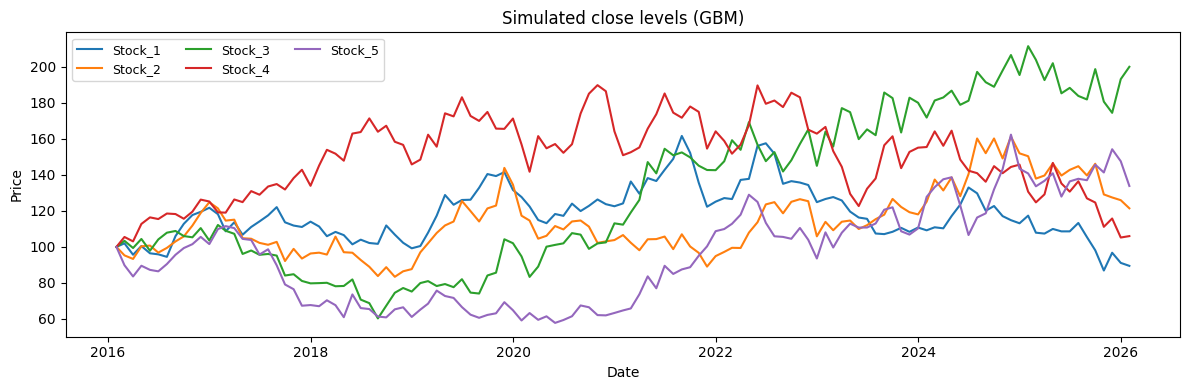

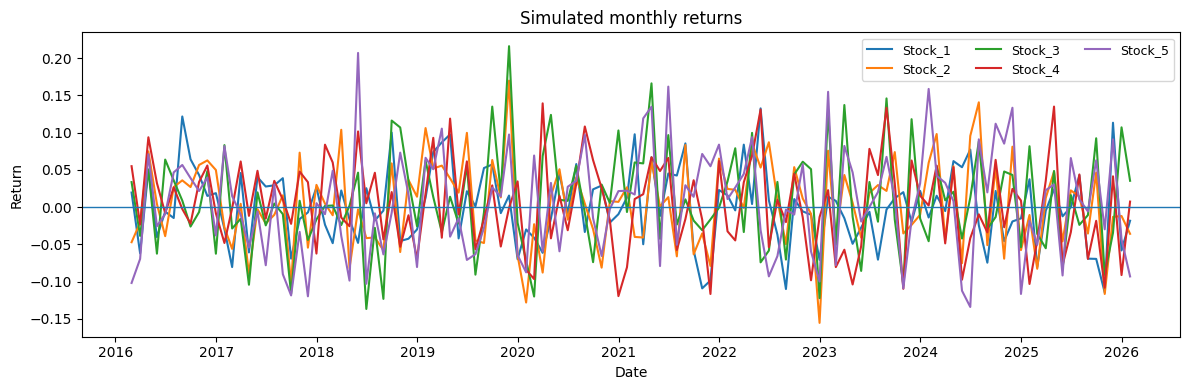

In [24]:
# --- 1) Close / price levels (all stocks on same plot) ---
plt.figure(figsize=(12,4))
for c in prices.columns:
    plt.plot(prices.index, prices[c], label=c)
plt.title("Simulated close levels (GBM)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

# --- 2) Monthly returns (all stocks on same plot) ---
plt.figure(figsize=(12,4))
for c in rets.columns:
    plt.plot(rets.index, rets[c], label=c)
plt.axhline(0.0, linewidth=1)
plt.title("Simulated monthly returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


In [25]:
def backtest_static_weights(rets, w, L=15):
    """
    Static-weights benchmark (Option A: decision-time indexing)

    - Use first L months as a burn-in (to match Markowitz starting point).
    - At each decision time t, action is the same fixed weights w,
      reward is next-month realized return: r_{p,t+1} = w' r_{t+1}.
    - Outputs are indexed by decision time t.
    """
    rets = rets.dropna(axis=0, how="any")
    T, n = rets.shape

    w = np.asarray(w, dtype=float).ravel()
    if w.size != n:
        raise ValueError(f"w must have length {n}, got {w.size}")

    # Optional: enforce budget normalization (comment out if you want strict input)
    if not np.isclose(w.sum(), 1.0):
        w = w / w.sum()

    weights = []
    dates = []
    port_rets = []

    # same loop bounds as Markowitz: t = L-1, ..., T-2
    for t in range(L-1, T-1):
        r_next = float(w @ rets.iloc[t+1].to_numpy())

        dates.append(rets.index[t])     # decision time
        weights.append(w.copy())        # same weights each period
        port_rets.append(r_next)

    weights = pd.DataFrame(weights, index=dates, columns=rets.columns)
    port_rets = pd.Series(port_rets, index=dates, name="portfolio_return_next")

    return port_rets, weights


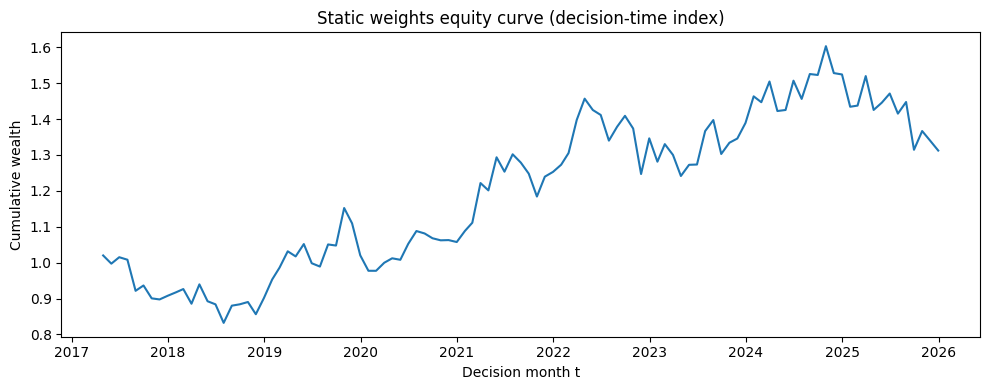

In [30]:
# equal-weight portfolio
w_eq = np.ones(rets.shape[1]) / rets.shape[1]

port_rets_static, wts_static = backtest_static_weights(rets, w_eq, L=15)

# plot equity curve
import matplotlib.pyplot as plt
equity_static = (1 + port_rets_static).cumprod()

plt.figure(figsize=(10,4))
plt.plot(equity_static)
plt.title("Static weights equity curve (decision-time index)")
plt.xlabel("Decision month t")
plt.ylabel("Cumulative wealth")
plt.tight_layout()
plt.show()


In [27]:
def backtest_static_trained_once(rets, L=15, lam=10.0,
                                 long_only=True, w_max=None,
                                 cov_shrink_alpha=0.0, mean_shrink_beta=0.0):
    """
    Train w once on the initial window rets[0:L], then hold it fixed.
    Option A indexing (decision time t, reward is next month return).

    Returns
    -------
    port_rets_static : pd.Series indexed by decision time t
        port_rets_static[t] = w' r_{t+1}
    weights_static : pd.DataFrame indexed by decision time t
        constant weights repeated
    w0 : np.ndarray
        the trained-once weights
    """
    rets = rets.dropna(axis=0, how="any")
    T, n = rets.shape
    if T <= L:
        raise ValueError(f"Need T > L to backtest. Got T={T}, L={L}")

    # --- fit once using the same initial estimation window ---
    window0 = rets.iloc[:L]
    mu0, Sigma0 = estimate_mu_sigma(window0,
                                    cov_shrink_alpha=cov_shrink_alpha,
                                    mean_shrink_beta=mean_shrink_beta)

    w0 = solve_markowitz_cvxpy(mu0, Sigma0, w_prev=None, lam=lam,
                               long_only=long_only, w_max=w_max,
                               turnover_penalty=0.0, turnover_limit=None)

    # --- now backtest as a static strategy (same timing as Markowitz) ---
    port_rets_static, weights_static = backtest_static_weights(rets, w0, L=L)

    return port_rets_static, weights_static, w0


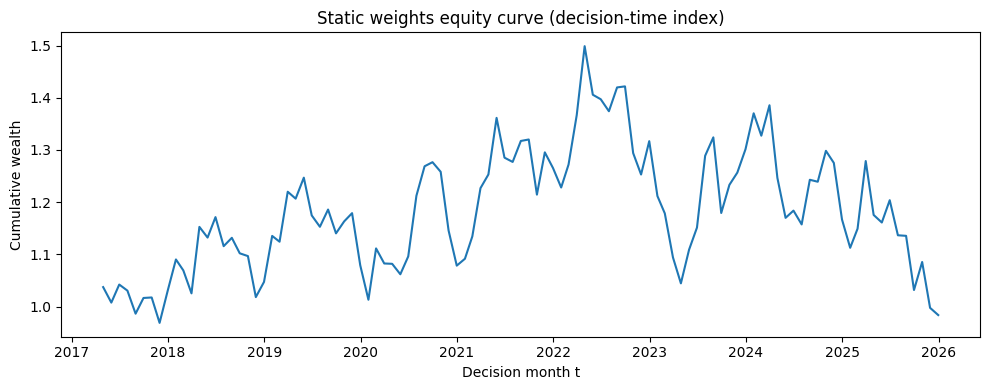

In [31]:

port_rets_static, wts_static, w0 = backtest_static_trained_once(rets)
equity_static = (1 + port_rets_static).cumprod()

plt.figure(figsize=(10,4))
plt.plot(equity_static)
plt.title("Static weights equity curve (decision-time index)")
plt.xlabel("Decision month t")
plt.ylabel("Cumulative wealth")
plt.tight_layout()
plt.show()
